# Setup

In [124]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, auc
import statsmodels.api as sm
from xgboost import XGBClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, r2_score


In [125]:
# Load dataset
credit_data = pd.read_csv("../data/cs-training.csv", index_col=0)

In [126]:
# Setup seaborn style for plots
sns.set_style("white")


In [127]:
# Display the first few rows of the dataset
credit_data.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


# EDA (Exploratory Data Analysis)
In this section, we are gonna get a first look of the dataset (shape, default rate,...) and the presence of missing values and duplicate lines will be checked.

## Quantify the missingness

In [128]:
# Display summary information about the dataset
credit_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: float64(

We can already observe missing data:
- `MonthlyIncome` has 120,269 of 150,000 → ~20% missing
- `NumberOfDependents` has 146076 of 150,000 → ~2.6% missing.  

Everything else is complete.


##  Proportion of defaulters

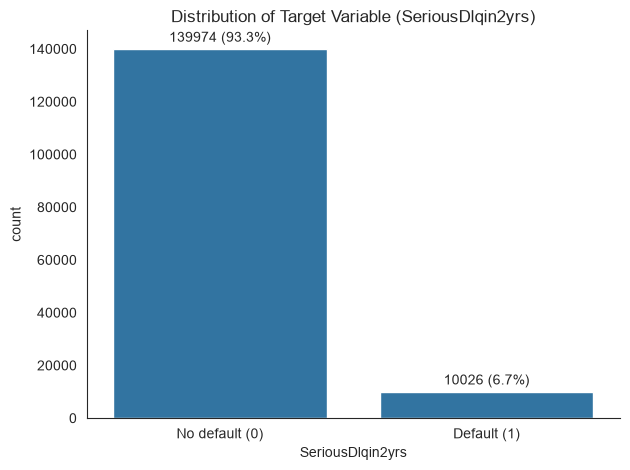

In [129]:
ax = sns.countplot(x="SeriousDlqin2yrs", data=credit_data)
plt.xticks([0, 1], ["No default (0)", "Default (1)"])
plt.title("Distribution of Target Variable (SeriousDlqin2yrs)")

# Annotate the bars with counts and percentages
total = len(credit_data)
for p in ax.patches:
    count = int(p.get_height())
    pct = count / total * 100
    ax.annotate(f"{count} ({pct:.1f}%)",
                xy=(p.get_x() + p.get_width() / 2, p.get_height()),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom")

sns.despine()   # remove top and right spines for a cleaner look
plt.tight_layout()  # adjust layout to prevent clipping of labelse
plt.show()

**6.7% default rate** is heavy imbalance. The accuracy trap is real: predict "no default" for all → 93.3% accuracy, zero defaulters caught. So we'll use AUC/Gini/KS and balance the classes.

## Default rate within each band
The idea: bin a continuous feature into bands, then plot the default rate within each band. If the default rate climbs (or falls) smoothly across bands, the feature discriminates risk; which is the whole point of a scorecard.  
There 2 stron candidates:
- `age`: Intuitively, we'd expect younger borrowers to default more (matches the negative correlation you saw).
- `RevolvingUtilizationOfUnsecuredLines`: We'd expect borrowers with higher credit card utilization to be more likely to default.

### Categorisation of `age`

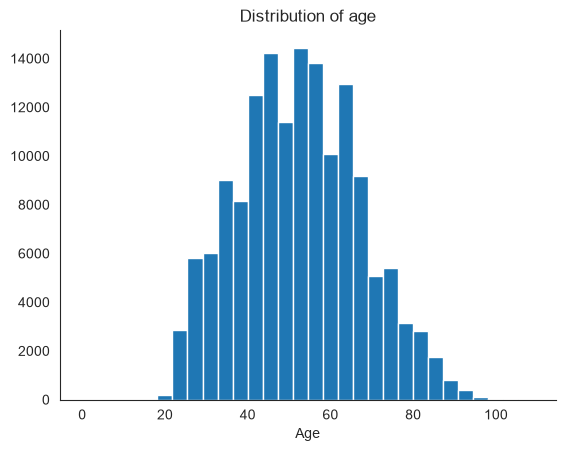

In [130]:
# Create a histogram of the 'age' variable
credit_data.age.hist(bins=30)
plt.title("Distribution of age")
plt.xlabel("Age")
plt.grid(False)
sns.despine()   # remove top and right spines for a cleaner look
plt.show()

In [131]:
# Create age bands using quantiles
age_band=pd.qcut(credit_data.age, q=10)

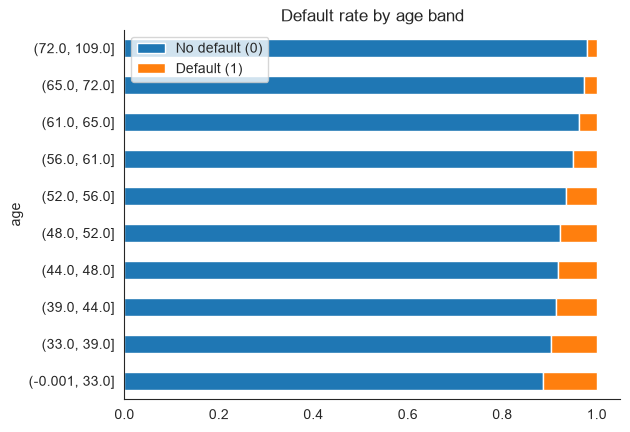

SeriousDlqin2yrs         0         1
age                                 
(-0.001, 33.0]    0.886450  0.113550
(33.0, 39.0]      0.904149  0.095851
(39.0, 44.0]      0.913602  0.086398
(44.0, 48.0]      0.918594  0.081406
(48.0, 52.0]      0.922973  0.077027
(52.0, 56.0]      0.934220  0.065780
(56.0, 61.0]      0.950290  0.049710
(61.0, 65.0]      0.962516  0.037484
(65.0, 72.0]      0.973348  0.026652
(72.0, 109.0]     0.978384  0.021616


In [132]:
# Create a crosstab to analyze the relationship between age bands and default rates
ct_age = pd.crosstab(age_band, credit_data.SeriousDlqin2yrs, normalize='index')
ct_age.plot(kind="barh", stacked=True)
plt.title("Default rate by age band")
plt.legend(labels=["No default (0)", "Default (1)"])
sns.despine()   # remove top and right spines for a cleaner look
plt.show()
print(ct_age)

The story is clear: the orange (default) slice shrinks steadily as age rises. Youngest band (21–33) defaults around 11–12%; oldest band (72+) down around 2–3%. So the relationship is essentially monotonic decreasing: older borrowers are safer, steadily.

### Categorisation of `UtilizationOfUnsecuredLines`

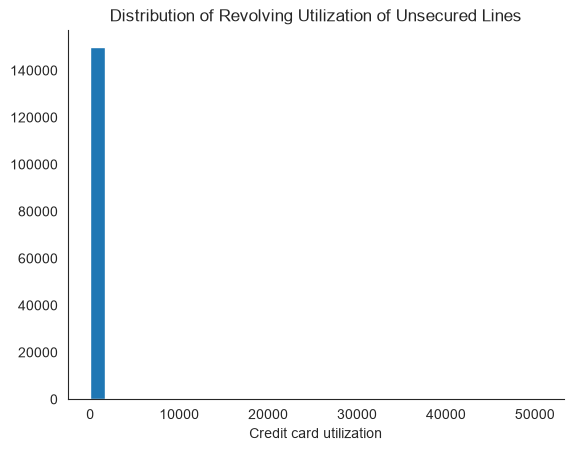

In [133]:
credit_data.RevolvingUtilizationOfUnsecuredLines.hist(bins=30)
plt.title("Distribution of Revolving Utilization of Unsecured Lines")
plt.xlabel("Credit card utilization")
plt.grid(False)
sns.despine()   # remove top and right spines for a cleaner look
plt.show()

Utilization is heavily concentrated near 0 (most people barely use their credit)

In [134]:
# Create utilization bands using quantiles
ct_utilization=pd.qcut(credit_data.RevolvingUtilizationOfUnsecuredLines, q=10)

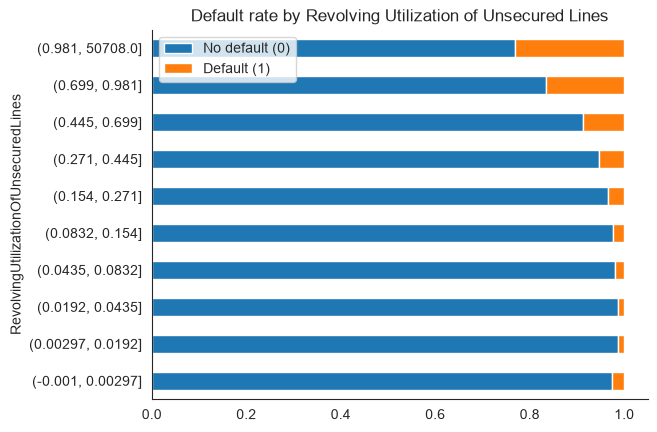

SeriousDlqin2yrs                             0         1
RevolvingUtilizationOfUnsecuredLines                    
(-0.001, 0.00297]                     0.974800  0.025200
(0.00297, 0.0192]                     0.986400  0.013600
(0.0192, 0.0435]                      0.986000  0.014000
(0.0435, 0.0832]                      0.980867  0.019133
(0.0832, 0.154]                       0.976267  0.023733
(0.154, 0.271]                        0.965267  0.034733
(0.271, 0.445]                        0.947533  0.052467
(0.445, 0.699]                        0.912000  0.088000
(0.699, 0.981]                        0.834133  0.165867
(0.981, 50708.0]                      0.768333  0.231667


In [135]:
# Create a crosstab to analyze the relationship between utilization bands and default rates
pd.crosstab(ct_utilization, credit_data.SeriousDlqin2yrs, normalize='index').plot(kind="barh", stacked=True)
plt.title("Default rate by Revolving Utilization of Unsecured Lines")
plt.legend(labels=["No default (0)", "Default (1)"])
sns.despine()   # remove top and right spines for a cleaner look
plt.show()

print(pd.crosstab(ct_utilization, credit_data.SeriousDlqin2yrs, normalize='index'))

It's not strictly monotonic:  
- (−0.001, 0.003]: 2.52%
- (0.003, 0.019]: **1.36% ← lower**
- (0.019, 0.044]: 1.40%

The very lowest band (essentially zero utilization) defaults more than the next two. So there's a small dip then rise before the strong monotonic climb.  
Apparently, people with zero revolving utilization aren't always the safest

So utilization is a genuine binning candidate (or nonlinear treatment), unlike age. The non-monotonicity is mild and the dominant signal is the steep monotonic rise. That's why we run XGBoost as a challenger. Trees capture that non-monotonic shape automatically. Logistic regression will partly miss it. We may well see XGBoost pull ahead largely because of variables like this.

## Duplicate lines
It is important to notice that with only ~10 features, most of them small whole numbers (age, counts of loans, counts of late payments), two different real customers can easily have identical values. Same age, same income, zero past-dues, two open loans… that's a common profile, not necessarily the same person duplicated.

In [136]:
# Check for duplicates
credit_data.duplicated().sum()

np.int64(609)

609 exact duplicate rows (0.41%). We decide to retain them. As explained earlier with ~10 mostly-discrete features, identical profiles are plausibly distinct customers rather than data-entry errors.

## Hunt for impossible/extreme values
This is the detective work that makes the cleaning step principled instead of arbitrary.

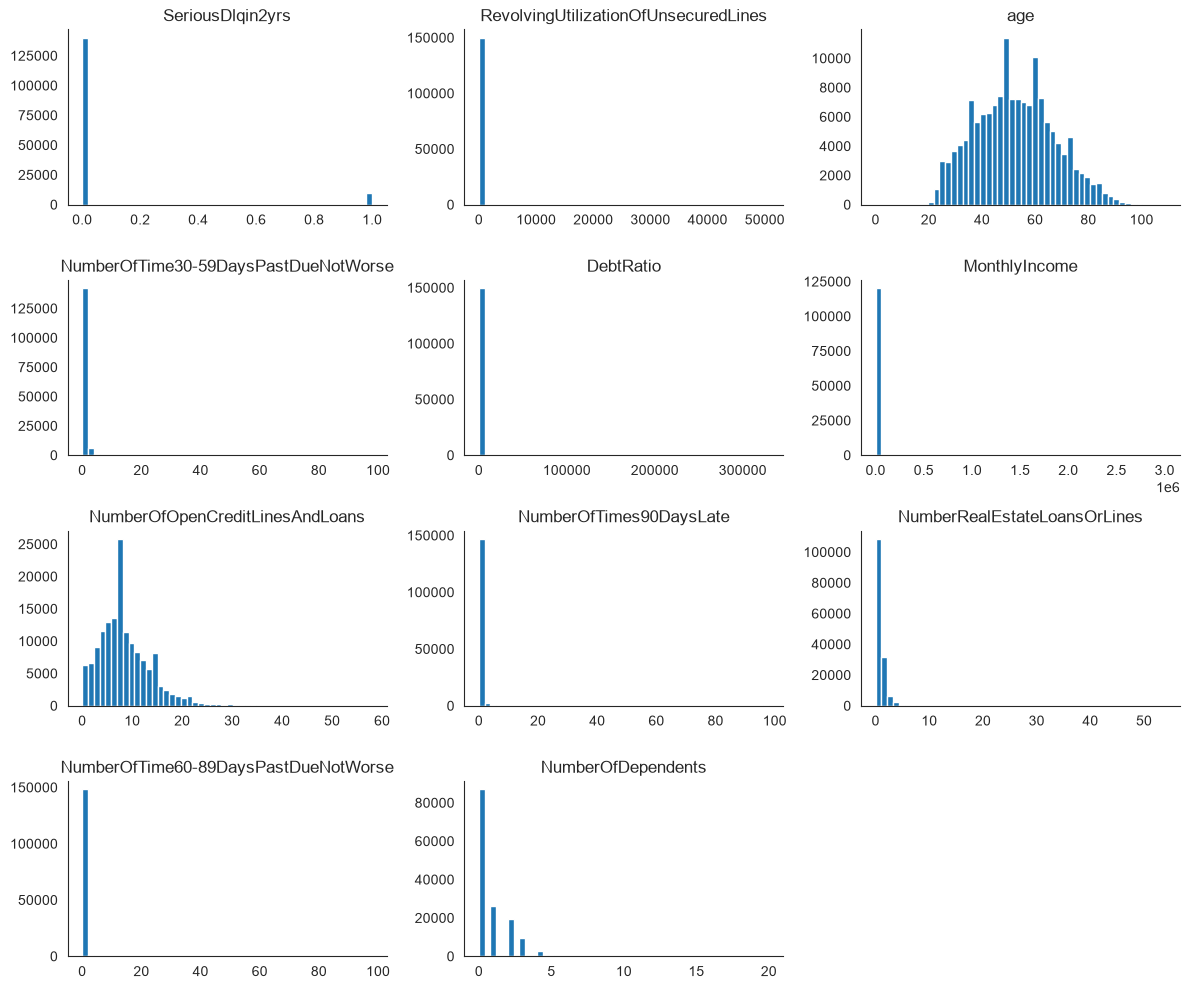

In [137]:
credit_data.hist(figsize=(12, 10), bins=50, grid=False)
plt.tight_layout()
sns.despine()   # remove top and right spines for a cleaner look
plt.show()

In [138]:
credit_data.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


We can divide our findings into 3 categories:

1. Clearly broken → must be fixed:
   - `RevolvingUtilization`, max 50,708. It's a ratio (75% is only 0.56). 50,708 is impossible.
   - `DebtRatio`, max 329,664. Same logic: a ratio sitting at 0.87 at the 75th percentile can't hit 329k.
   - `age`, min 0. Impossible! A 0-year-old borrower doesn't exist.

2. Looks broken but isn't → leave it:
   - `age`, max 109. Rare, but possible. Centenarians exist.
   - `MonthlyIncome`, min 0. Actually plausible. A student or unemployed person can have €0 income. Not clearly an error.  
   Max 3M is also possible. It could be for instance a CEO with a high income.  
   The real income problem is the ~20% missing values, not the zeros.
   - `NumberRealEstateLoansOrLines`, max 54. Extreme, yes, but it's a genuine long tail (a heavy property investor)

3. Placeholder code:
   - The three past-due columns are suspicious. Look: the mean is ~0.3, the 75th percentile is 0, then suddenly max = 98 for all three. That's not a person who was late 98 times, it's a placeholder code (96 and 98) the data provider used for "unknown". Let's check it forst and then fix it.

In [139]:
# Check for sentinel sentinel codes
credit_data["NumberOfTimes90DaysLate"].value_counts().sort_index()

NumberOfTimes90DaysLate
0     141662
1       5243
2       1555
3        667
4        291
5        131
6         80
7         38
8         21
9         19
10         8
11         5
12         2
13         4
14         2
15         2
17         1
96         5
98       264
Name: count, dtype: int64

That's the proof! Read the shape of it: counts fall off smoothly 0 → 17, then a gap (nothing from 18 to 95), then a weird cluster at 96 (×5) and 98 (×264).  
Real late-payment counts don't teleport from 17 to 98. That gap is the signature of sentinel codes. The data provider stuffed "unknown/missing" into 96 and 98. The same pattern is in the other two past-due columns.  
We'll use an explicit `NaN/NULL`, never a magic number because magic numbers cause exactly confusion.

## Presence of multicollinearity
 It matters specifically for logistic regression. It assumes predictors aren't strongly correlated with each other. When two features are highly correlated (multicollinearity), the model can't tell which one drives the outcome. The coefficients become unstable and their signs/sizes stop being interpretable 

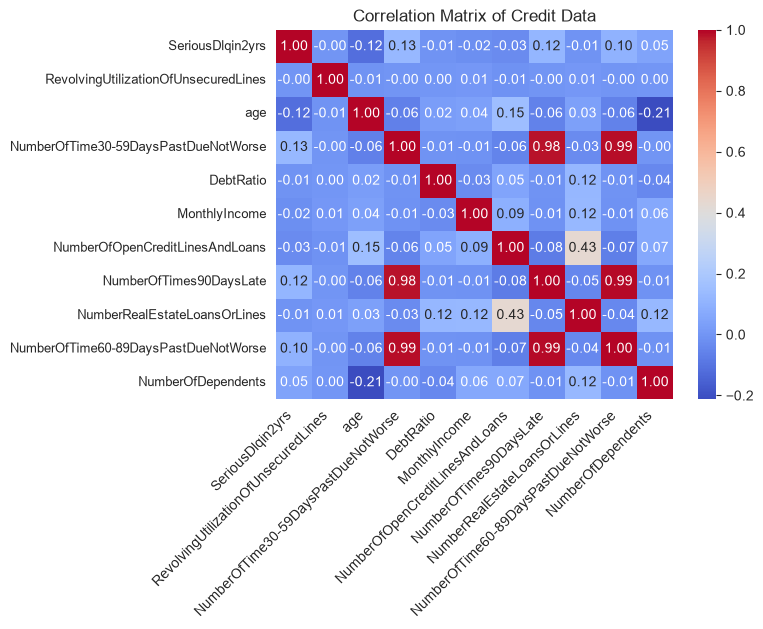

In [140]:
sns.heatmap(credit_data.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Credit Data")
plt.xticks(rotation=45, ha="right") # rotate x-tick labels for better readability
plt.yticks(fontsize=9) # change y-tick font size
plt.show()

The heatmap has just flagged a severe multicollinearity on the the three past-due columns:
- 30-59 ↔ 90-days-late: **0.98**
- 30-59 ↔ 60-89: **0.99**
- 90-days-late ↔ 60-89: **0.99**  

 Those three columns are almost the same variable. This is exactly the problem the heatmap exists to catch, and it directly threatens our production model. We will deal later with that.


**Why so correlated?**  
- **Delinquency cascades**: someone 30–59 days late is more likely to roll into 60–89 and then 90+. That genuine behavioral co-movement creates some correlation.  
- **269 Sentinel rows**: those rows had 96/98 in all three columns simultaneously. So those 269 jointly-extreme rows are inflating the 0.99.

# Cleaning
We'll apply the fixes our EDA justified, one at a time.

## Past-due sentinels (96/98)

Three options, each with a cost:
- **Delete the rows**. We can throw away the customer entirely, including their valid `age`, `income`, everything. Worse: if the 96/98 group isn't random (say they're disproportionately defaulters), deleting them biases your sample. Rarely worth it for a handful of bad cells.
- **Replace with NA, then impute**. This is the most logically consistent with calling them "unknown" — unknown = missing. But here's the trap: if we then impute to the median (which is 0 for these columns), we'll be relabelling these people as "never late" — potentially the exact opposite of the truth.
- **Cap at the legit max (17)**. Assumes 96/98 were really "very high late-payment counts" that got miscoded, and keeps them as high-risk.  

Let's verify if the 96/98 rows behave like high-risk or low-risk borrowers?

In [141]:
# 96/98: high-risk or low-risk?
mask = credit_data["NumberOfTimes90DaysLate"].isin([96, 98])
print("Default rate, 96/98 rows:", credit_data.loc[mask, "SeriousDlqin2yrs"].mean())
print("Default rate, everyone:   ", credit_data["SeriousDlqin2yrs"].mean())

Default rate, 96/98 rows: 0.5464684014869888
Default rate, everyone:    0.06684


There it is — 54.6% vs 6.7%. The 96/98 group defaults at over eight times the baseline.-! That's not noise; it's one of the strongest risk signals in the whole dataset.
So the data just made our decision for us:
- **Impute to 0?** Catastrophic — we'll relabel people who default half the time as "never late". We'll be feeding the model a lie.
- **Delete them?** We'll delete our highest-risk segment. Throwing away gold.
- **Cap at the legit max (17)?** Keeps them parked at the top of the real range.  

One nuance: capping at 17 may slightly understate them, they might be worse than a real 17. A refinement is to keep a "was-sentinel" flag so the model can learn they're extra-risky.

In this  dataset the 96/98 values tend to appear in the same rows across all three past-due columns: a person flagged in one is usually flagged in all. One flag instead of one per column could help us to avoid redundancy and multicollinearity (a problem for logistic regression especially).

In [142]:
# Check if the same rows are flagged in the other two columns
s1 = credit_data["NumberOfTime30-59DaysPastDueNotWorse"].isin([96, 98])
s2 = credit_data["NumberOfTimes90DaysLate"].isin([96, 98])
s3 = credit_data["NumberOfTime60-89DaysPastDueNotWorse"].isin([96, 98])
print("Rows flagged in each:", s1.sum(), s2.sum(), s3.sum())
print("Rows flagged in ALL three:", (s1 & s2 & s3).sum())

Rows flagged in each: 269 269 269
Rows flagged in ALL three: 269


Perfect overlap! They're literally the same rows. So three separate flags would be three identical columns, perfectly redundant.  
Decision settled: one combined flag

In [143]:
# Create the flag
credit_data["PastDue_sentinel"]=(s1 | s2 | s3).astype(int)
credit_data["PastDue_sentinel"].value_counts()

PastDue_sentinel
0    149731
1       269
Name: count, dtype: int64

We've already seen that 17 was the legitimate max for the 90-days colum. Now, we're gonna check the other two's real max, cap the three columns and confirm the 96/98 are gone.

In [144]:
# Check legitimate max
NumberOfTime_PastDue= ["NumberOfTime30-59DaysPastDueNotWorse",
                       "NumberOfTimes90DaysLate", "NumberOfTime60-89DaysPastDueNotWorse"]
max_NumberOfTime_PastDue={} # Dictionary to store the legitimate max for each column

for col in NumberOfTime_PastDue:
    legit_max=credit_data.loc[~ credit_data[col].isin([96, 98]), col].max()
    print(f"{col}: legit max = {legit_max}")
    max_NumberOfTime_PastDue[col]=legit_max

# Replace the sentinel values with the legitimate max
for col in NumberOfTime_PastDue:
    credit_data.loc[credit_data[col].isin([96, 98]), col]=max_NumberOfTime_PastDue[col]
    # Verify that the sentinels are gone
    assert not credit_data[col].isin([96, 98]).any(), f"{col} still contains sentinels"

NumberOfTime30-59DaysPastDueNotWorse: legit max = 13
NumberOfTimes90DaysLate: legit max = 17
NumberOfTime60-89DaysPastDueNotWorse: legit max = 11


## Impossible age
We replace the impossible `age` of 0 with the median age.

In [145]:
## Fix: age == 0
credit_data.loc[credit_data["age"] == 0, "age"] = credit_data.loc[credit_data.age != 0, "age"].median() #computes the median from valid ages only
assert (credit_data["age"] == 0).sum() == 0, "There are still age=0 rows"

## Ratio outliers
Now the ratio outliers of `RevolvingUtilizationOfUnsecuredLines` and `DebtRatio`.  
Plan: winsorise at the 99th percentile (cap anything above it down to that value).  
First check whether the anomaly carries signal before deciding how to treat it. 

In [146]:
print("Default rate, above 99th pct for RevolvingUtilizationOfUnsecuredLines", 
      credit_data.loc[credit_data.RevolvingUtilizationOfUnsecuredLines >1, "SeriousDlqin2yrs"].mean())
print("Default rate, above 99th pct for DebtRatio", credit_data.loc[credit_data.DebtRatio >1, "SeriousDlqin2yrs"].mean())
print("Default rate, everyone:", credit_data.loc[:, "SeriousDlqin2yrs"].mean())

Default rate, above 99th pct for RevolvingUtilizationOfUnsecuredLines 0.3724781692261367
Default rate, above 99th pct for DebtRatio 0.06520192389788541
Default rate, everyone: 0.06684


This is a genuinely important result:
- Utilization > 1 → 37.2% default vs 6.7% baseline. Massively high-risk.
- DebtRatio > 1 → 6.5% default vs 6.7% baseline. Basically identical to baseline.  

**Utilization**: extreme values are strongly high-risk → winsorise.  

**DebtRatio**: the extremes carry no directional signal, they default at the baseline rate. That tells you these huge values are mostly noise/artifacts, not risk. Here's the likely cause, and it's worth checking: DebtRatio = debt ÷ income. When income is missing or near-zero, that denominator blows the ratio up to meaningless thousands.  Capping is still wise (huge values destabilise logistic regression).

In [147]:
# Check if the high debt ratio rows have missing monthly income
print("number of rows with debt ratio higher than 1:", ((credit_data.DebtRatio) >1).sum())
print("number of rows with missing value within monthly income:", 
      credit_data.MonthlyIncome.isna().sum())
print("commmon lines between debt ratio higher than 1 and missing value within monthly income", 
      ((credit_data.DebtRatio >1) & (credit_data.MonthlyIncome.isna())).sum())

number of rows with debt ratio higher than 1: 35137
number of rows with missing value within monthly income: 29731
commmon lines between debt ratio higher than 1 and missing value within monthly income 27904


 Put it together:

27,904 / 29,731 = 94% of the missing-income rows have DebtRatio > 1.  
27,904 / 35,137 = 79% of the DebtRatio > 1 rows have missing income.

The theory holds: the DebtRatio anomaly is almost entirely an income-missingness artifact. When income (the denominator) is absent, the ratio computes to garbage. That's why those extremes default at the baseline rate, they're not risky borrowers, they're a side effect of a missing field.

In [148]:
# Check the quantiles for RevolvingUtilizationOfUnsecuredLines
credit_data.RevolvingUtilizationOfUnsecuredLines.quantile([0.5, 0.9, 0.95, 0.99])

0.50    0.154181
0.90    0.981278
0.95    1.000000
0.99    1.092956
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

In [149]:
# Cap the outliers
util_cap = credit_data["RevolvingUtilizationOfUnsecuredLines"].quantile(0.99)
credit_data["RevolvingUtilizationOfUnsecuredLines"] = \
    credit_data["RevolvingUtilizationOfUnsecuredLines"].clip(upper=util_cap)

# Verify that the outliers have been capped
assert credit_data["RevolvingUtilizationOfUnsecuredLines"].max() <= util_cap, "There are still outliers in RevolvingUtilizationOfUnsecuredLines"

In [150]:
# Check the quantiles for DebtRatio
credit_data.loc[credit_data.MonthlyIncome.notna(), "DebtRatio"].quantile([0.5, 0.9, 0.95, 0.99])

0.50      0.296023
0.90      0.763149
0.95      1.128771
0.99    661.820000
Name: DebtRatio, dtype: float64

We cap at the 95th percentile of the income because the 99th percentile is clearly an outlier.

In [151]:
# Cap the outliers
dr_cap = credit_data.loc[credit_data.MonthlyIncome.notna(), "DebtRatio"].quantile(0.95)
credit_data["DebtRatio"] = credit_data["DebtRatio"].clip(upper=dr_cap)

# Verify that the outliers have been capped
assert credit_data.loc[:, "DebtRatio"].max() <= dr_cap, "There are still outliers in DebtRatio"

## Missing values
 Last cleaning: fixing the missing values → `MonthlyIncome` (~20% missing) and `NumberOfDependents` (~2.6%).  
 Plan: impute both with the median, and keep a "was missing" flag for income (missingness could be informative).  

Before proceeding, we will assess whether missing income is predictive of default. To do this, we will use **Weight of Evidence (WoE)** and **Information Value (IV)**, which quantify the strength of the relationship.

In [152]:
# Creating flags for missing values in MonthlyIncome and NumberOfDependents
credit_data["MonthlyIncome_missing"] = credit_data.MonthlyIncome.isna().astype(int)
#credit_data["NumberOfDependents_missing"] = credit_data.NumberOfDependents.isna().astype(int)

In [153]:
# Check the relationship between missingness in MonthlyIncome and the target variable
pd.crosstab(credit_data.MonthlyIncome_missing, credit_data.SeriousDlqin2yrs, normalize="index")

SeriousDlqin2yrs,0,1
MonthlyIncome_missing,,
0,0.930514,0.069486
1,0.943863,0.056137


Apparently, income-present rows default at 6.95%, missing-income rows at 5.61%. So missing income is associated with slightly lower default, weak, and a touch counterintuitive (we might've expected missing data to signal risk; here it doesn't).

In [154]:
def woe_iv(df, feature, target="SeriousDlqin2yrs"):
    """
    Compute Weight of Evidence (WoE) and Information Value (IV) for a feature.

    For each category of `feature`, compares its share of good (target=0) vs
    bad (target=1) cases. WOE = log(dist_good / dist_bad) per category;
    IV = (dist_good - dist_bad) * WOE per category, summed into Total_IV to
    gauge how predictive the feature is overall.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset containing `feature` and `target` columns.
    feature : str
        Column to bucket and evaluate (categorical, or already binned).
    target : str, default "SeriousDlqin2yrs"
        Binary target column (0 = good, 1 = bad).

    Returns
    -------
    pd.DataFrame
        One row per category of `feature` with N, Dist_Good, Dist_Bad, WOE,
        IV, and Total_IV (the feature's overall IV, repeated on every row).
    """
    n_good = (df[target] == 0).sum()
    n_bad  = (df[target] == 1).sum()
    rows   = []
    for cat in df[feature].unique():
        g = ((df[feature]==cat) & (df[target]==0)).sum()
        b = ((df[feature]==cat) & (df[target]==1)).sum()
        dist_g = g / n_good if n_good > 0 else 0
        dist_b = b / n_bad  if n_bad > 0  else 0
        woe    = np.log(dist_g / dist_b) if (dist_g > 0 and dist_b > 0) else 0
        iv     = (dist_g - dist_b) * woe
        rows.append({'Category': cat, 'N': (df[feature]==cat).sum(),
                     'Dist_Good': dist_g, 'Dist_Bad': dist_b,
                     'WOE': woe, 'IV': iv})
    result = pd.DataFrame(rows)
    result['Total_IV'] = result['IV'].sum()
    return result

In [155]:
# Compute WOE/IV for MonthlyIncome_missing variable
woe_iv(credit_data, "MonthlyIncome_missing")

,Category,N,Dist_Good,Dist_Bad,WOE,IV,Total_IV
0,0,120269,0.79952,0.833533,-0.041662,0.001417,0.007741
1,1,29731,0.20048,0.166467,0.185917,0.006324,0.007741


There it is: **Total IV = 0.0077**. Put it on the table: that's **below 0.02 → "useless**. The missing-income flag has essentially **no predictive power**.  

Our sign reading also checks out: the missing bin (1) has a positive WoE (+0.19) — in this good/bad convention, positive = proportionally more goods = lower risk. That matches our earlier finding (missing income defaulted 5.6% vs 7.0%). The maths and the data agree.

**So what do you do with the flag?** Honest, you can drop it. It adds complexity and noise to a logistic model for no lift. However, we'll keep it to record which rows had imputed income but it'll be excluded it from `features` of predecitive model.

Now we will impute `MonthlyIncome` and `NumberOfDependents` using their median values.  
For completeness, we note that we will not conduct the same missingness investigation for `NumberOfDependents` as we do for `MonthlyIncome`, since it has only ~2.6% missing values. A missingness indicator at this level is unlikely to exceed an IV threshold of 0.02. There are simply too few missing observations for the “missing” category to carry meaningful signal, regardless of how it behaves. As a result, the expected value of running the full missingness flag and IV analysis is low.

In [156]:
# Impute missing values for MonthlyIncome and NumberOfDependents with their respective medians
missing_cols = ["MonthlyIncome", "NumberOfDependents"]
for col in missing_cols:
    credit_data.loc[credit_data[col].isna(), col] = credit_data[col].median()
    assert credit_data[col].isna().sum() == 0, f"There are still missing values in {col}"

In [157]:
# Check that the imputation worked and review the summary stats for the imputed columns
print(credit_data[["MonthlyIncome", "NumberOfDependents"]].describe())
credit_data.isna().sum().sum()   # should be 0

       MonthlyIncome  NumberOfDependents
count   1.500000e+05       150000.000000
mean    6.418455e+03            0.737413
std     1.289040e+04            1.107021
min     0.000000e+00            0.000000
25%     3.903000e+03            0.000000
50%     5.400000e+03            0.000000
75%     7.400000e+03            1.000000
max     3.008750e+06           20.000000


np.int64(0)

Everything looks fine, there is no missing value.

## Income transformation
**For logistic regression**: the 3M value inflates the standard deviation enormously, so when you standardize, all your real incomes (3k–23k) get crushed into a tiny sliver near zero while the outlier sits far out.  
**For XGBoost**: the magnitude doesn't distort anything but the order matters. That's why we are gonna proceed with a log-transform instead fo winsorising.

In [158]:
# Log-transform MonthlyIncome to reduce skewness and handle zero values
credit_data["MonthlyIncome_log"] = np.log1p(credit_data["MonthlyIncome"])

We keep raw ´MonthlyIncome´ (in $) for the dashboard and EDA — "€5,400" is readable, "8.59 log-units" is not. We will use ´MonthlyIncome_log´ as the model feature in your explicit feature list

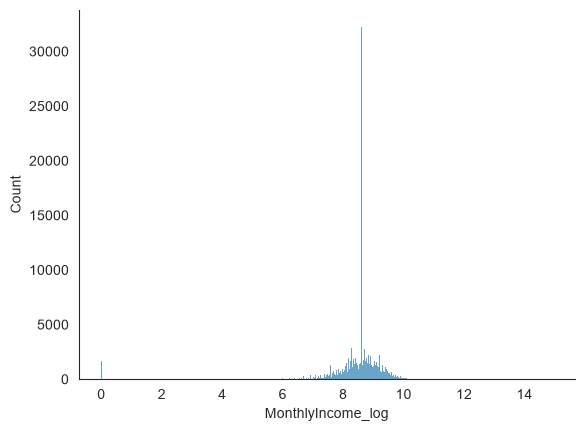

In [159]:
sns.histplot(data=credit_data, x="MonthlyIncome_log")
sns.despine()   # remove top and right spines for a cleaner look
plt.show()

That worked. The 3M tail is gone. Those extreme values are now pulled into the ~14–15 region (barely visible), and the bulk of incomes form a roughly bell-shaped cluster around 8–9. That's exactly what you want for logistic regression. The log did its job. The small spike at 0 is the genuine zero-income rows (`log1p(0) = 0`), handled cleanly. 

# Train/test split
Before training the model, the dataset was divided into separate training and testing sets to ensure an unbiased evaluation of predictive performance. The training set was used to learn patterns from the data, while the test set was held out and used only for final evaluation on unseen observations.

A stratified train/test split was applied to preserve the original proportion of default and non-default cases across both subsets. This is particularly important for imbalanced classification problems, as it ensures that each dataset remains representative of the overall target distribution and leads to more reliable performance estimates.

Performing the split before model training and evaluation also helps prevent information leakage and supports a more realistic assessment of how the model is expected to perform on new data.

In the ideal textbook workflow, the dataset is first split into training and test sets. All exploratory data analysis (EDA) and preprocessing steps are then performed exclusively on the training set, with the learned transformations applied later to the test set. This approach ensures strict separation between training and evaluation data, eliminating any risk of data leakage, meaning no information from the test set can influence the model during training.

In this project, a different ordering was used: EDA and data cleaning were performed on the full dataset prior to the final train/test split. This choice was made for two main reasons.

First, it was a pedagogical decision. Working on a single, unified dataset made it significantly easier to understand and iterate on data quality issues and transformations. Identifying sentinel values, diagnosing the `DebtRatio` anomaly, and deciding on the income transformation were more straightforward when the entire dataset could be analyzed without repeatedly separating train and test subsets. The focus at this stage was on building intuition and understanding the data rather than enforcing strict modelling protocol.

Second, the risk of meaningful data leakage is minimal in this specific context. The transformations applied such as imputation statistics, winsorization thresholds, and the log transformation are based on robust aggregate statistics computed over a large dataset (~150,000 observations). As a result, the difference between statistics computed on the full dataset versus only the training subset is negligible. Consequently, any potential leakage introduced by this ordering is unlikely to have a material impact on model performance or evaluation integrity.


In [160]:
# Define features and target variable
features = ['RevolvingUtilizationOfUnsecuredLines', 'age',
            'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio',
            'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines',
            'NumberOfDependents', 'PastDue_sentinel', 'MonthlyIncome_log']
X = credit_data[features]

y=credit_data.SeriousDlqin2yrs

# Split the dataset into training and testing sets, stratifying by the target variable to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=66, test_size=0.3, stratify=y)

The feature selection was guided by both statistical evidence and interpretability considerations:

* **Kept only one past-due feature (`NumberOfTime30-59DaysPastDueNotWorse`)** to address the strong multicollinearity observed across the past-due variables (correlation ≈ 0.99). Among the available options, the 30–59 days feature showed the highest correlation with the target, making it the most informative representative of this group.

* **Selected `MonthlyIncome_log` instead of raw `MonthlyIncome`** to preserve the benefits of the log transformation, which reduces skewness and improves the feature’s relationship with the target.

* **Removed `MonthlyIncome_missing` and raw `MonthlyIncome`** because `MonthlyIncome_missing` showed very limited predictive power (IV = 0.008), while retaining both raw and transformed income variables would introduce redundancy.

* **Retained `PastDue_sentinel`** since it captures an additional high-risk signal associated with sentinel values (54.6% default rate), complementing the information provided by the selected past-due feature.


# Logistic Regression (the production model)
This is the regulatory standard: interpretable, converts to a scorecard, gives odds ratios.

In [161]:
# Z-score standardisation
scaler = StandardScaler()
X_train_slr = scaler.fit_transform(X_train)   # LEARN mean/std from train, apply to train
X_test_slr = scaler.transform(X_test)        # APPLY train's mean/std to test (no re-learning)

In [162]:
# Fit a logistic regression model with balanced class weights to handle class imbalance
logreg = LogisticRegression(class_weight="balanced", max_iter=1000).fit(X_train_slr, y_train)

In [163]:
# Evaluate the model using ROC AUC score
pd_logreg = logreg.predict_proba(X_test_slr)[:, 1]  # get probabilities for the positive class
print("AUC: ", roc_auc_score(y_test, pd_logreg))



AUC:  0.8263646675481247


It's a good score for logisitc regression.

In [164]:
# Display the coefficients of the logistic regression model
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': logreg.coef_[0]
})

print(coef_df)

                                feature  coefficient
0  RevolvingUtilizationOfUnsecuredLines     0.844942
1                                   age    -0.298543
2  NumberOfTime30-59DaysPastDueNotWorse     0.670514
3                             DebtRatio     0.058862
4       NumberOfOpenCreditLinesAndLoans     0.087338
5          NumberRealEstateLoansOrLines     0.065091
6                    NumberOfDependents     0.047979
7                      PastDue_sentinel    -0.334892
8                     MonthlyIncome_log    -0.027056


All the signs of the coefficients look logical except `PastDue_sentinel` which is negative. We measured that sentinel rows default at 54.6%!  A negative coefficient says "being a sentinel makes you safer," which flatly contradicts the data.  
It's probably come from  multicollinearity, coefficients can take unexpected signs due to this.  Here's the mechanism: the 269 sentinel rows are the same rows sitting at the capped maximum (13) of the `NumberOfTime30-59` column. So that past-due column (+0.67) already absorbs their risk signal and the redundant sentinel flag gets left with a spurious negative coefficient as the model tries to split one effect across two near-identical features.  

## Update the model
Now there are two things to do:
1. **Verify the redundancy**: correlation (or VIF) between `PastDue_sentinel` and `NumberOfTime30-59DaysPastDueNotWorse`
2. **Likely drop** `PastDue_sentinel` from the  Logisitic regression: the past-due column already carries its signal, and removing it should clean up the signs.

In [165]:
# Check the correlation between NumberOfTime30-59DaysPastDueNotWorse and PastDue_sentinel
credit_data[["NumberOfTime30-59DaysPastDueNotWorse", "PastDue_sentinel"]].corr()

,NumberOfTime30-59DaysPastDueNotWorse,PastDue_sentinel
NumberOfTime30-59DaysPastDueNotWorse,1.0000,0.6121
PastDue_sentinel,0.6121,1.0000


0.61 is a moderate correlation. By the rule of thumb (|r| > 0.8 = severe), that's below the red line.  
However pairwise correlation could understate the redundancy here, because the overlap is concentrated. At the top of that column, the two features are nearly identical. But the correlation gets diluted by the huge mass of low past-due values (0, 1, 2…) where the sentinel flag is 0. So r = 0.61 averages near-perfect overlap at the high end" with "no overlap at the low end.

**Decision: drop `PastDue_sentinel` from the logistic regression**. The capped past-due column (+0.67) already flags those rows as maximum-risk, so the flag is redundant and destabilizing the signs.

## Refit the model without `PastDue_sentinel`

In [166]:
def refit_without_feature(feature_to_drop, features, df=credit_data, target=y):
    '''
    Refit a logistic regression model after removing a specified feature.

    This function removes `feature_to_drop` from the provided `features` list,
    re-creates the feature matrix `X`, performs a stratified train/test split,
    standardises the features with `StandardScaler`, fits a logistic regression
    model (with `class_weight='balanced'`), prints the test AUC and the
    model coefficients, and returns the fitted model and related objects.

    Parameters
    ----------
    feature_to_drop : str
        Name of the feature to remove from `features` before refitting.
    features : list of str
        Original list of feature names to consider (one will be removed).
    df : pandas.DataFrame, optional
        Dataset containing the features. Default is the global `credit_data`.
    target : array-like or pandas.Series, optional
        Target values aligned with `df`. Default is the global `y`.

    Returns
    -------
    logreg : sklearn.linear_model.LogisticRegression
        The fitted logistic regression model trained on the reduced feature set.
    scaler : sklearn.preprocessing.StandardScaler
        Scaler fitted on the training features (useful to transform new data).
    X_test_slr : numpy.ndarray
        Standardised test features corresponding to `y_test`.
    y_test : pandas.Series or ndarray
        True target values for the test set.

    Notes
    -----
    - The function prints the AUC computed on the test split and a DataFrame of
      coefficients for quick inspection. It uses `random_state=66` and
      `test_size=0.3` for reproducibility and stratification by `target`.
    '''

    # Drop feature(s) to the features list
    keep = [f for f in features if f != feature_to_drop]   # copy, no mutation

    # Re-define X with the reduced feature set
    X = df[keep]

    # Re-split the dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, target, random_state=66, test_size=0.3, stratify=target)

    # Z-score standardisation
    scaler = StandardScaler()
    X_train_slr = scaler.fit_transform(X_train)
    X_test_slr = scaler.transform(X_test)

    # Fit logistic regression model on the reduced feature set
    logreg = LogisticRegression(class_weight="balanced", max_iter=1000).fit(X_train_slr, y_train)

    # Evaluate the model using ROC AUC score
    pd_logreg = logreg.predict_proba(X_test_slr)[:, 1]  # get probabilities for the positive class
    print(f"AUC after dropping {feature_to_drop}: ", roc_auc_score(y_test, pd_logreg))

    # Display the coefficients of the logistic regression model
    coef_df = pd.DataFrame({
        'feature': X.columns,
        'coefficient': logreg.coef_[0]
    })

     # return the model, scaler, and feature and their coefficient for later use
    return logreg, scaler, X_train, X_train_slr, X_test, X_test_slr, y_test, pd_logreg, coef_df  

In [167]:
# Refit the model after removing "PastDue_sentinel" and display the coefficients
logreg, scaler, X_train, X_train_slr, X_test, X_test_slr, y_test, pd_logreg, coef_df = refit_without_feature("PastDue_sentinel", features)
print(coef_df)

AUC after dropping PastDue_sentinel:  0.8257757524989563
                                feature  coefficient
0  RevolvingUtilizationOfUnsecuredLines     0.846318
1                                   age    -0.296612
2  NumberOfTime30-59DaysPastDueNotWorse     0.617031
3                             DebtRatio     0.061228
4       NumberOfOpenCreditLinesAndLoans     0.093755
5          NumberRealEstateLoansOrLines     0.063905
6                    NumberOfDependents     0.051020
7                     MonthlyIncome_log    -0.025753


Now look at what dropping the flag achieved:
1. **Every sign is now sensible**. No more wrong sign. And in the same time, removing the flag didn't flip any other sign, confirming it was the lone troublemaker.
2. **AUC barely moved: 0.8264 → 0.8258** (−0.0006). That's the proof the flag was redundant, removing it cost essentially nothing. So you removed a wrong-signed, destabilizing feature at zero performance cost. Cleaner, fully interpretable, equally predictive. That's exactly the trade we want.

In [168]:
# Refit the model after removing "PastDue_sentinel"
features.remove("PastDue_sentinel")
assert "PastDue_sentinel" not in features, "PastDue_sentinel was not removed from features list"

Regarding the coefficients because they're on scaled features, the magnitudes are directly comparable. Utilization (0.85) is our strongest driver, then 30–59 past-due (0.62), then age (−0.30). Income, debt ratio, and the count variables are weak contributors.

## Coefficients significance
Now we see the actual p-values on our coefficients. As a recall:
- p-value < 0.01 Highly significant
- 0.01 < p-value < 0.05 Significant
- 0.05 < p-value < 0.10 Weakly significant
- p-value > 0.10 Not significant

In [169]:
# Fit a logistic regression model using statsmodels to get detailed summary statistics

X_train_scaled_df = pd.DataFrame(X_train_slr, columns=X_train.columns, index=X_train.index)
X_train_sm = sm.add_constant(X_train_scaled_df)

logit = sm.Logit(y_train, X_train_sm).fit()
print(logit.summary())

Optimization terminated successfully.
         Current function value: 0.200164
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:       SeriousDlqin2yrs   No. Observations:               105000
Model:                          Logit   Df Residuals:                   104991
Method:                           MLE   Df Model:                            8
Date:              mar., 23 juin 2026   Pseudo R-squ.:                  0.1843
Time:                        12:14:03   Log-Likelihood:                -21017.
converged:                       True   LL-Null:                       -25765.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -3.1990      0.0

Almost everything is 0.000, except:
- `MonthlyIncome_log`: p = 0.376 → NOT significant. Even with 105,000 training rows, income does not reliably predict default once the other variables are in the model. One explanation coud be that income's signal is largely already captured by utilization and debt ratio, so it adds nothing on its own.
- `NumberRealEstateLoansOrLines`: p = 0.031 → significant at 5% but not 1%.  

**Decision**: `MonthlyIncome_log` is dropped from our model, it has near-zero effect. `NumberRealEstateLoansOrLines` is kept.

## Refit the model without `MonthlyIncome_log`

In [170]:
# Refit the model after removing "MonthlyIncome_log" and display the coefficients
logreg, scaler, X_train, X_train_slr, X_test, X_test_slr, y_test, pd_logreg, coef_df = refit_without_feature("MonthlyIncome_log", features)
print(coef_df)

AUC after dropping MonthlyIncome_log:  0.8256911167920028
                                feature  coefficient
0  RevolvingUtilizationOfUnsecuredLines     0.845917
1                                   age    -0.299169
2  NumberOfTime30-59DaysPastDueNotWorse     0.616837
3                             DebtRatio     0.067178
4       NumberOfOpenCreditLinesAndLoans     0.091291
5          NumberRealEstateLoansOrLines     0.059692
6                    NumberOfDependents     0.050014


**AUC 0.8257** is essentially identical to before (0.8258). Income was dead weight, confirmed. And every one of the 7 remaining coefficients is sensibly signed: utilization, past-due, debt ratio, credit lines, real estate, dependents all push risk up; age pulls it down.

In [171]:
# Remove "MonthlyIncome_log" from the features list for future reference
features.remove("MonthlyIncome_log")
assert "MonthlyIncome_log" not in features, "MonthlyIncome_log was not removed from features list"

## Interpretation

In [172]:
coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])
print(coef_df)

                                feature  coefficient  odds_ratio
0  RevolvingUtilizationOfUnsecuredLines     0.845917    2.330113
1                                   age    -0.299169    0.741434
2  NumberOfTime30-59DaysPastDueNotWorse     0.616837    1.853057
3                             DebtRatio     0.067178    1.069486
4       NumberOfOpenCreditLinesAndLoans     0.091291    1.095588
5          NumberRealEstateLoansOrLines     0.059692    1.061510
6                    NumberOfDependents     0.050014    1.051286


Reading the final table in plain words:
- **Utilization (2.33)**: strongest driver → +1 standard deviation more than doubles the odds of default.
- **30–59 past-due (1.85)** →  +1  standard deviation raises odds ~85%.
- **age (0.74)**: protective →  +1 standard deviation drops odds ~26%.
- Debt ratio, open lines, real estate, dependents (1.05–1.10) →  each a weak ~5–10% bump  

Every feature is significant, sensibly signed, and reads as a defensible risk multiplier.

# XGBoost (the challenger)
Will XGBoost beat the LR's 0.826? XGBoost will likely win because it can capture non-linearities and interactions that logistic regression structurally cannot. LR models the log-odds as a straight line, each feature has one fixed, monotonic slope. XGBoost (trees) can bend: non-monotonic shapes, thresholds, and interactions.  
We’ve already identified a non-monotonic relationship in `UtilizationOfUnsecuredLines`(zero-utilization people defaulting slightly more than low-but-nonzero ones). Logisitc regression is forced to draw a straight line through that and misses the wobble. XGBoost can model the dip directly. So if XGBoost wins, that's the kind of thing it's exploiting.

In [173]:
from xgboost import XGBClassifier
# Create a gradient boosted tree model
spw = (y_train == 0).sum() / (y_train == 1).sum() # compute scale_pos_weight to handle class imbalance
gbt = XGBClassifier(learning_rate = 0.2,max_depth = 4,  scale_pos_weight=spw,
                    eval_metric="auc", random_state=66)

# Train the gradient boosted tree
gbt.fit(X_train, y_train)

# Predict probabilities of default
gbt_preds_prob=gbt.predict_proba(X_test)[:, 1]

roc_auc_score(y_test, gbt_preds_prob)
print("XGBoost AUC: ", roc_auc_score(y_test, gbt_preds_prob))

XGBoost AUC:  0.8326578970335788


XGBoost **0.8327** vs LR **0.8257** → a gap of just **+0.007 (under 1 AUC point)**  
**Why so close?** Our data is probably well-cleaned and mostly monotonic: age was monotonic, utilization mostly so (just that small low-end dip). There's limited nonlinear structure left for XGBoost to exploit beyond what LR already captures. So LR is grabbing nearly all the available signal, and XGBoost's flexibility only buys a sliver more.  

When the challenger beats the production model by this little, the interpretability of LR clearly wins. We're giving up almost nothing in ranking power for complete transparency. That's a cleaner argument for "LR in production, XGBoost as challenger" than a big gap would have been. It shows the simple, explainable model is essentially as good here.

can you create cheat sheet about XGBClassifier in my notion "Cheat sheet" page?

# Evaluate: AUC, Gini, KS, ROC, decile gains
This is where you put both models side by side on the metrics usually reported.

## A metrics table 
Let's study AUC, Gini, KS for both models.

In [174]:
# Compare the performance of the logistic regression and XGBoost models using AUC, Gini, and KS statistics
results = []
for name, proba in [("Logistic Regression", pd_logreg), ("XGBoost", gbt_preds_prob)]:
    auc = roc_auc_score(y_test, proba)
    fpr, tpr, _ = roc_curve(y_test, proba)
    ks = max(tpr - fpr)
    results.append({"Model": name, "AUC": auc, "Gini": 2*auc - 1, "KS": ks})

pd.DataFrame(results).round(4)

,Model,AUC,Gini,KS
0,Logistic Regression,0.8257,0.6514,0.5061
1,XGBoost,0.8327,0.6653,0.5158


XGBoost ranks slightly better, but the margin is small enough that LR's interpretability wins for production.

## ROC curves

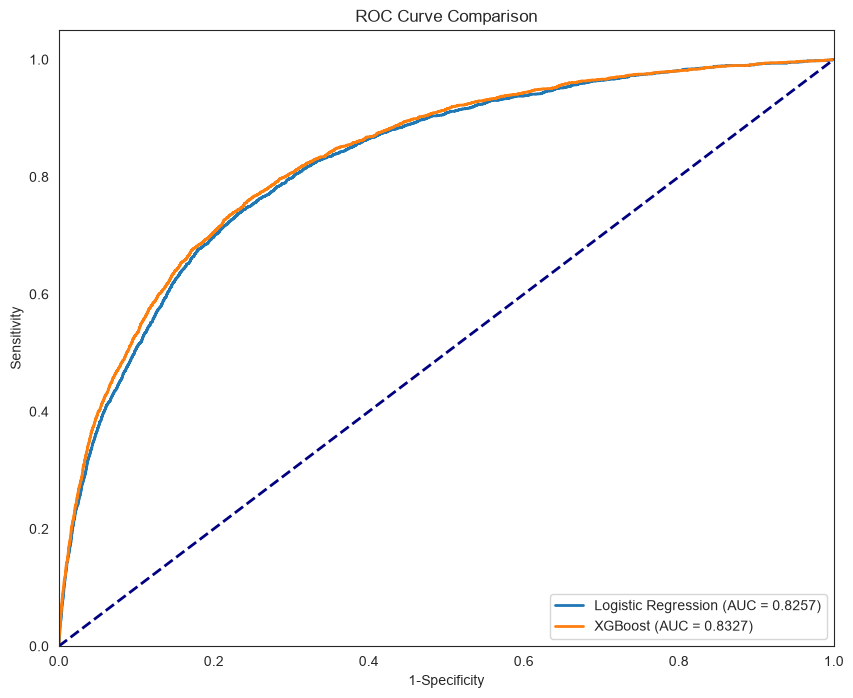

In [175]:
# Models
models_pred = {"Logistic Regression": pd_logreg, "XGBoost":  gbt_preds_prob}

# Initialize a dictionary to store AUC - ROC scores
auc_scores = {}

# Plot the ROC curves
plt.figure(figsize=(10, 8))

for name, prediction in models_pred.items():
    auc_scores[name] = roc_auc_score(y_test, prediction)
    
    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, prediction)
    
    # Plot ROC curve
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc_scores[name]:.4f})')

# Plot the diagonal 50% line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    
# Customize the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity')
plt.ylabel('Sensitivity')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.show()

The two curves are almost on top of each other, with XGBoost (orange) sitting barely above LR (blue) (exactly the ~0.007 AUC gap). If the gap were large, we'd see clear daylight between them; instead they're nearly indistinguishable. That's the honest, correct picture: two strong models, one marginally better at ranking.  
Both curves bow sharply toward the top-left corner and sit far above the navy diagonal (the random-guessing 0.5 baseline). The further a curve pushes toward that top-left corner, the better.

## Decile/gains 
This is the business-facing view that bins borrowers into risk deciles and shows the observed default rate climbing across them. It's where your model stops being abstract AUC and becomes "who do we decline?"Here's a example of concrete business question: *"If we rank everyone by predicted risk and look at the riskiest 10%, what fraction of all our defaulters did we catch?"*


In [176]:
def gains_table(y_true, y_pred):
    """
    Build a decile-level gains table from true binary labels and predicted probabilities.

    Parameters
    ----------
    y_true : pandas.Series
        Binary ground-truth labels (0/1). Only the values are used.
    y_pred : array-like or pandas.Series
        Predicted probabilities or scores (higher means higher predicted default risk).

    Returns
    -------
    pandas.DataFrame
        Gains table indexed by `decile` (1 = riskiest / highest PD ... 10 = safest)
        with columns:
        - n: number of observations in the decile
        - defaults: number of observed defaults (sum of `y_true`) in the decile
        - default_rate: defaults / n
        - lift: default_rate divided by overall default rate in `y_true`
        - cum_pct_defaults: cumulative proportion of total defaults captured up to that decile

    Notes
    -----
    - Predictions are binned into 10 quantile-based deciles using `pd.qcut`.
    - Decile numbering is flipped so that lower numbers indicate higher risk (decile 1 = riskiest).
    """
    
    df = pd.DataFrame({"y_true": y_true.values, "pd": y_pred})

    # 1. Bin into deciles. labels=False gives integer codes 0–9 (0 = lowest PD).
    df["decile"] = pd.qcut(df["pd"].rank(method="first"), q=10, labels=False)

    # 2. Flip so decile 1 = riskiest (highest PD), decile 10 = safest.
    df["decile"] = 10 - df["decile"]

    # 3. Aggregate per decile.
    gains = df.groupby("decile").agg(
        n=("y_true", "size"),
        defaults=("y_true", "sum"),
    ).sort_index()

    # 4. Derived columns.
    gains["default_rate"] = gains["defaults"] / gains["n"]
    gains["lift"] = gains["default_rate"] / df["y_true"].mean()
    gains["cum_pct_defaults"] = gains["defaults"].cumsum() / gains["defaults"].sum()

    return gains

In [177]:
# Plot the gains table for the logistic regression model
gains_table(y_true=y_test, y_pred=pd_logreg)

,n,defaults,default_rate,lift,cum_pct_defaults
decile,,,,,
1,4500,1328,0.295111,4.414894,0.441489
2,4500,634,0.140889,2.107713,0.652261
3,4500,347,0.077111,1.153590,0.767620
4,4500,229,0.050889,0.761303,0.843750
5,4500,164,0.036444,0.545213,0.898271
6,4500,105,0.023333,0.349069,0.933178
7,4500,82,0.018222,0.272606,0.960439
8,4500,55,0.012222,0.182846,0.978723
9,4500,36,0.008000,0.119681,0.990691


The model sorts applicants by risk well enough that the riskiest 10% default 4–5× more than average, and by reviewing just the riskiest 30% we'd catch over three-quarters of all defaults. So we focus effort where the risk actually is.  

**1. The default rate falls monotonically**  
29.5% → 14.1% → 7.7% → 5.1% → 3.6% → 2.3% → 1.8% → 1.2% → 0.80% → 0.62%
Every decile is lower than the one above it, with no reversals. That clean monotonic descent is exactly what good ranking looks like, the model orders borrowers by risk with no stumbles. (A weak model would show the rate bouncing around).  

**2. Lift in decile 1 = 4.41**  
 The riskiest 10% of borrowers default at 29.5% vs. the 6.7% portfolio average.So they're 4.4× more likely to default than a randomly chosen borrower.  

 **3. Cumulative capture is genuinely strong**  
 - Decile 1 alone captures 44% of all defaulters in just 10% of the population.
- Top 2 deciles → 65%.
- Top 3 deciles → 77%.  

So by reviewing only the riskiest 30% of applicants, we'd catch over three-quarters of all defaults. 


In [178]:
gains_table(y_true=y_test, y_pred=gbt_preds_prob)

,n,defaults,default_rate,lift,cum_pct_defaults
decile,,,,,
1,4500,1402,0.311556,4.660904,0.466090
2,4500,599,0.133111,1.991356,0.665226
3,4500,337,0.074889,1.120346,0.777261
4,4500,225,0.050000,0.748005,0.852061
5,4500,154,0.034222,0.511968,0.903258
6,4500,105,0.023333,0.349069,0.938165
7,4500,76,0.016889,0.252660,0.963431
8,4500,48,0.010667,0.159574,0.979388
9,4500,35,0.007778,0.116356,0.991024


 XGBoost's advantage is real but concentrated at the very top. It's a bit better at identifying the riskiest 10–20%, which makes sense (that's where nonlinear structure pays off). By decile 3 the two have basically converged. 

## Threshold view

This is where "PD score" becomes "who gets the loan".

In [179]:
# Defie a threshold for classifying predicted probabilities
threshold=0.3

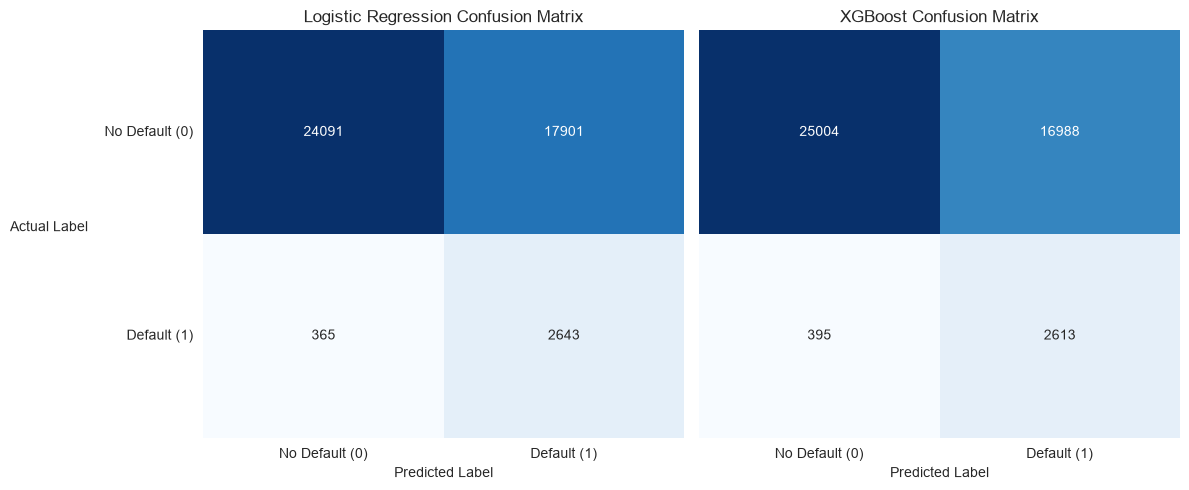

In [180]:
# Build confusion matrices for both models
n_models = len(models_pred)

fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))

if n_models == 1:
    axes = [axes]

for i, (ax, (name, prediction)) in enumerate(zip(axes, models_pred.items())):

    cm = confusion_matrix(y_test, prediction >= threshold)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["No Default (0)", "Default (1)"],
        yticklabels=["No Default (0)", "Default (1)"]
    )

    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted Label")
    
    # Horizontal y ticks
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    # Remove y label only for second column
    if i == 1:
        ax.set_ylabel("")
        ax.set_yticklabels([])   # optional → removes tick labels too
    else:
        ax.set_ylabel("Actual Label", rotation=0, labelpad=40)

plt.tight_layout()
plt.show()

For the LR, at a 0.3 threshold, the model captures 88% of all defaulters (recall = 2,643 / 3,008), missing only 365. This high recall reflects a deliberately conservative, risk-averse operating point: in lending, a missed defaulter (false negative) typically costs the lost loan principal, whereas a wrongly declined applicant (false positive) costs only forgone interest margin. Because the false-negative cost dominates, a low threshold that maximizes recall can be appropriate.  

Both models produce near-identical confusion matrices at this threshold (LR: 2,643 TP / 365 FN; XGBoost: 2,613 TP / 395 FN), consistent with their marginal AUC difference (0.826 vs 0.833). This reinforces the conclusion that the interpretable logistic regression is the appropriate production choice, with XGBoost offering negligible operational gain."

In [181]:
# classification report for logistic regression model
from sklearn.metrics import classification_report
print(classification_report(y_test, pd_logreg >= threshold,
                            target_names=["No Default", "Default"]))

              precision    recall  f1-score   support

  No Default       0.99      0.57      0.73     41992
     Default       0.13      0.88      0.22      3008

    accuracy                           0.59     45000
   macro avg       0.56      0.73      0.47     45000
weighted avg       0.93      0.59      0.69     45000



At threshold 0.3 (LR), Default class: recall 0.88, precision 0.13. So we now catch 88% of all defaulters. However we have to pay a price, precision is only 0.13. Everyone the model flags as "default" at 0.3, only 13% actually default; 87% are good borrowers we'd decline.  

At 6.7% imbalance, accuracy is a garbage metric. A model that approves everyone scores 93% accuracy. Ours "fell" to 59% precisely because we are flagging risk.  

The threshold is a pure business dial, not a statistical one. 0.3 vs 0.5 vs 0.8 isn't "right or wrong". That's a credit-policy decision (and a profitability calculation), not something the model can tell us.

In [182]:
# Build a threhold sweep table to see how precision, recall, F1, and confusion matrix components change at different thresholds
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

rows = []
for t in [0.3, 0.5, 0.8]:
    y_hat = (pd_logreg >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_hat).ravel()
    rows.append({
        "threshold": t,
        "TP": tp, "FP": fp, "FN": fn,
        "recall":    recall_score(y_test, y_hat),
        "precision": precision_score(y_test, y_hat),
        "F1":        f1_score(y_test, y_hat),
    })

sweep = pd.DataFrame(rows)
sweep

,threshold,TP,FP,FN,recall,precision,F1
0,0.3,2643,17901,365,0.878657,0.128651,0.224440
1,0.5,2237,10001,771,0.743684,0.182791,0.293454
2,0.8,981,1673,2027,0.326130,0.369631,0.346521


As the threshold rises, recall falls (0.88 → 0.33) and precision rises (0.13 → 0.37). The two move in opposite directions, that is the tradeoff, made undeniable in one glance. And the FP/FN columns show the human consequence: at 0.3 you decline ~18,000 good borrowers to miss only 365 defaulters; at 0.8 you wrongly decline far fewer (1,673) but let 2,027 defaulters through.

In [183]:
# Save the metrics table to a CSV file for Power BI reporting
metrics_df = pd.DataFrame(results).round(4)   # if not already named
metrics_df.to_csv("../reports/powerbi/metrics_table.csv", index=False)

In [184]:
# Save the scored test set to a CSV file for Power BI reporting. 
# This includes the true labels, predicted probabilities from both the logistic regression and XGBoost models.
scored = X_test.copy()
scored["y_true"]     = y_test.values
scored["pd_logreg"]  = pd_logreg
scored["pd_xgb"]     = gbt_preds_prob
scored.to_csv("../reports/powerbi/scored_test.csv", index=False)

In [ ]:
# Add decile column to the scored test set for Power BI reporting. 
# The deciles are calculated based on the predicted probabilities from the logistic regression model, with 1 being the riskiest and 10 being the safest.
scored = pd.read_csv("../reports/powerbi/scored_test.csv")
scored["decile"] = 10 - pd.qcut(scored["pd_logreg"].rank(method="first"),ga
                                q=10, labels=False)   # 1 = riskiest
scored.to_csv("../reports/powerbi/scored_test.csv", index=False)

In [187]:
# Build a gains table for the logistic regression model and save it to a CSV file for Power BI reporting.
gains_logreg = gains_table(y_test, pd_logreg)
gains_logreg.to_csv("../reports/powerbi/gains_logreg.csv")   # keeps decile as a column